In [1]:
import pandas as pd
import numpy as np

# Load Datasets

In [2]:
dataset = 'esol_delaney'
split = 0
df_all = pd.read_csv(f'../0_datasets/regression/{dataset}.csv')
df_perf = pd.read_pickle('rf_regression_solubility/df_performance.pkl')
df_expl = pd.read_pickle('rf_regression_solubility/df_explanation.pkl').query('dataset == @dataset and split == @split')
df_expl.shape

(223, 11)

In [3]:
# get train smiles
train_indices = df_perf.loc[(df_perf.split == split) & (df_perf.dataset == dataset)].iloc[0].train_index
train_smiles = df_all.nonstereo_aromatic_smiles.to_numpy()[train_indices]

In [4]:
df_expl.head()

,dataset,split,smiles,y_true,y_pred,fragExplainer_result,fragExplainer_expected_value,shap_result,shap_expected_value,atom_id_to_bits,frag_to_atom_ids
0,esol_delaney,0,ClCC(Cl)Cl,-1.48,-1.505550,{0: -0.4723700000000004},-1.03318,"[0.0, -0.17569224561401142, 0.0, 0.0, 0.0, -2....",-3.203017,"{2: [1, 232, 1137], 1: [80, 1525], 3: [914, 16...","{0: [0, 1, 2, 3, 4]}"
1,esol_delaney,0,Clc1cc(Cl)c(Cl)c(Cl)c1,-4.63,-7.003215,{0: -5.970035000000007},-1.03318,"[0.0, 0.007942612676899899, 0.0, 0.0, 0.0, -5....",-3.203017,"{3: [151, 366, 1380], 7: [151, 366, 1380], 1: ...","{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}"
2,esol_delaney,0,Cc1cccc(C)c1C,-3.20,-3.081380,{0: -2.048200000000003},-1.03318,"[0.0, 0.00961002187613758, 0.0, 0.0, 0.0, 1.34...",-3.203017,"{7: [252, 1152, 1380], 3: [1039, 1088, 1873], ...","{0: [0, 1, 2, 3, 4, 5, 6, 7, 8]}"
3,esol_delaney,0,ClCCCl,-1.06,-1.233280,{0: -0.20009999999999972},-1.03318,"[0.0, 0.025225373218258938, 0.0, 0.0, 0.0, -2....",-3.203017,"{1: [80, 631, 1456], 2: [80, 1456], 0: [1109, ...","{0: [0, 1, 2, 3]}"
4,esol_delaney,0,Brc1cc(Br)cc(Br)c1,-5.60,-3.436555,{0: -2.4033749999999996},-1.03318,"[0.0, 0.011200746008157694, 0.0, 0.0, 0.0, 4.3...",-3.203017,"{0: [728, 1631], 4: [728, 1631], 7: [728, 1631...","{0: [0, 1, 2, 3, 4, 5, 6, 7, 8]}"


# Get Values per Fragment

In [5]:
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs, MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags

In [6]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]    

In [7]:
df_expl['fragments_SMILES'] = df_expl.smiles.apply(get_BRICS_fragments_as_SMILES)

In [8]:
r = df_expl.fragExplainer_result.to_list() # list of result dicts
r_ = [list(d.values()) for d in r] # turn dict into simple list
list_of_shap = [i for j in r_ for i in j] # flatten list
s = df_expl.fragments_SMILES.to_list() # list of list of smiles
list_of_smiles = [smiles for l in s for smiles in l] # flatten list

# assemble new dataframe
df_frag_single = pd.DataFrame({'smiles': list_of_smiles,
                               'value': list_of_shap})
# groupby SMILES, get all values and calculate mean and std
df_analysis = df_frag_single.groupby('smiles')['value'].apply(np.array).reset_index(name='values')
df_analysis['n_fragments'] = df_analysis['values'].apply(len)
df_analysis['mean'] = df_analysis['values'].apply(np.mean)
df_analysis['std'] = df_analysis['values'].apply(np.std)

# Filter list of fragments

In [9]:
n_appearance = 3 # minimum number of appearances in the whole dataset
df_analysis = df_analysis.loc[df_analysis.n_fragments >= n_appearance]
df_analysis.shape

(24, 5)

In [10]:
df_analysis.shape

(24, 5)

In [11]:
# only one attachment point
def filter_single_attachment(smiles):
    if smiles.count('*') == 1:
        return True
    else:
        return False

In [12]:
df_analysis = df_analysis.loc[df_analysis.smiles.apply(filter_single_attachment)]
df_analysis.shape

(15, 5)

# Combine Molecules

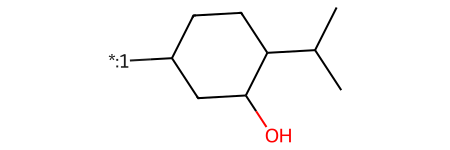

In [122]:
# choose an appropriate core
# core_smiles = 'C1([*:3])CC([*:1])CC([*:2])C1'
# core_smiles = 'C1CC([*:1])CC([*:2])C1'
core_smiles = 'C1C([*:1])CCC(C(C)C)C1(O)'
core_mol = MolFromSmiles(core_smiles)
n_attachment_points = 1# 3
attachments_symmetrically_equivalent = True
core_mol

In [123]:
# generate list of tuples containing the substituent ant the mean and std contribution
sub_mean_std = [(smiles, mean, std) for smiles, mean, std in zip(df_analysis.smiles, df_analysis['mean'], df_analysis['std'])]

In [124]:
def add_attachment_point_number_to_connection_point(smiles, number):
    return smiles.replace('*', f'[*:{number}]')

In [125]:
from itertools import product, combinations_with_replacement
from rdkit.Chem import molzip, RWMol

if attachments_symmetrically_equivalent:
    iterator = combinations_with_replacement(sub_mean_std, n_attachment_points)
else:
    product = product(sub_mean_std, n_attachment_points)


result_list = []

for out in iterator:

    smiles = [i[0] for i in out]
    means = [i[1] for i in out]
    stds = [i[2] for i in out]
    smiles_processed = [add_attachment_point_number_to_connection_point(sm, idx+1) for idx, sm in enumerate(smiles)]
    tmp_mol = RWMol(core_mol)
    [tmp_mol.InsertMol(MolFromSmiles(sm)) for sm in smiles_processed]
    tmp_mol = molzip(tmp_mol)
    result_list.append((MolToSmiles(tmp_mol, canonical=True), means, stds))

In [126]:
df_combs = pd.DataFrame({'smiles': [i[0] for i in result_list],
                         'means': [i[1] for i in result_list],
                         'stds': [i[2] for i in result_list]})
df_combs.shape

(15, 3)

In [127]:
# now apply some filtering and post-processing

# remove duplicates
df_combs = df_combs.drop_duplicates(subset='smiles')
df_combs['sum_mean_attributions'] = df_combs.means.apply(sum)

def adding_stds(list_of_stds):
    stds = np.array(list_of_stds)
    return np.sqrt(np.sum(np.square(stds)))
df_combs['std'] = df_combs.stds.apply(adding_stds) # asssume no covariance


df_combs


,smiles,means,stds,sum_mean_attributions,std
0,CCC(=O)C1CCC(C(C)C)C(O)C1,[0.36034916666666755],[0.1364315967004735],0.360349,0.136432
1,CC(C)C1CCC(C(C)(C)C)CC1O,[-0.9568916250000018],[0.2458847680506278],-0.956892,0.245885
2,CC(=O)C1CCC(C(C)C)C(O)C1,[0.4798714375000005],[0.25385416741892936],0.479871,0.253854
3,CC(C)C1CCC(C(C)C)C(O)C1,[-0.4311509797178139],[0.10045042729134734],-0.431151,0.100450
4,CC(C)C1CCC(C(F)(F)F)CC1O,[-0.710642],[0.14243254842062533],-0.710642,0.142433
5,CC(C)C1CCC(C(N)=O)CC1O,[0.7620871666666664],[0.03198415674916028],0.762087,0.031984
6,CCC1CCC(C(C)C)C(O)C1,[-0.0927399281609192],[0.10769189331028611],-0.092740,0.107692
7,C=CCC1CCC(C(C)C)C(O)C1,[-0.26073750000000073],[0.06998237070168323],-0.260738,0.069982
8,CCCC1CCC(C(C)C)C(O)C1,[-0.7926958333333345],[0.06697387861188446],-0.792696,0.066974
9,CCCCC1CCC(C(C)C)C(O)C1,[-1.188964552083333],[0.28722552629096],-1.188965,0.287226


In [128]:
# check if created molecules are in training set
df_combs = df_combs.query('smiles not in @train_smiles')
df_combs.shape

(15, 5)

# Load Model and Get Predictions

In [129]:
from pickle import load

In [130]:
with open(f'rf_regression_solubility/models/model_rfr_{dataset}_split_{split}.pkl', 'rb') as f:
    rfr = load(f)

In [131]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

mfpgen = GetMorganGenerator(radius=2,
                            fpSize=2048,
                            )
fps = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in df_combs.smiles])
fps.shape

(15, 2048)

In [132]:
preds = rfr.predict(fps)
df_combs['prediction'] = preds

# Plot Results

Text(0, 0.5, 'predicted solubility')

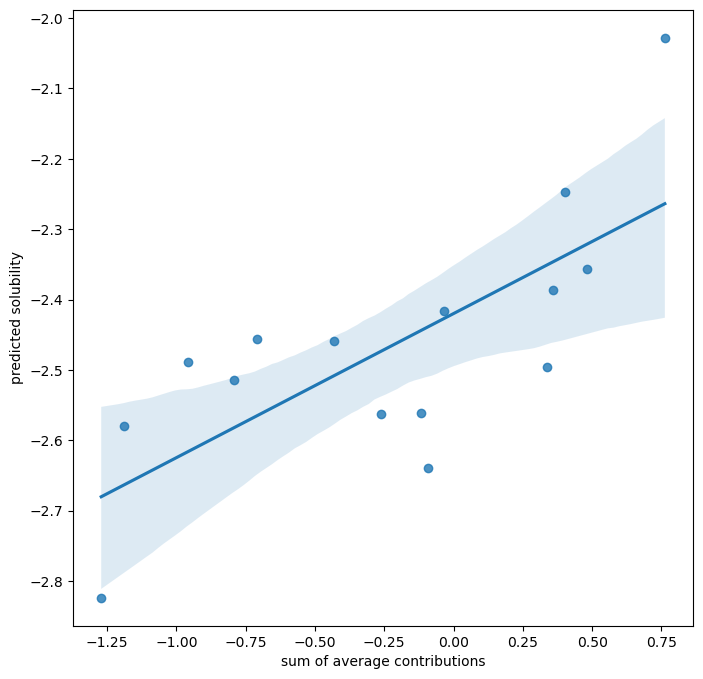

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 1, figsize=(8, 8))

sns.regplot(data=df_combs,
            x='sum_mean_attributions',
            y='prediction',
            ax=axs)
axs.set_xlabel('sum of average contributions')
axs.set_ylabel('predicted solubility')


In [136]:
from scipy.stats import pearsonr, spearmanr

print(pearsonr(df_combs.sum_mean_attributions, df_combs.prediction))
print(spearmanr(df_combs.sum_mean_attributions, df_combs.prediction))

PearsonRResult(statistic=np.float64(0.7289616763388197), pvalue=np.float64(0.00204811561885283))
SignificanceResult(statistic=np.float64(0.7321428571428571), pvalue=np.float64(0.0019129636009785611))
